# Diabetes Classification


From the _[American Diabetes Association](https://diabetes.org/about-diabetes/common-terms)_:

> Diabetes is a condition where the body’s blood glucose (blood sugar) levels are higher than normal (hyperglycemia) resulting from the body's inability to use or store blood glucose for energy. In type 1 diabetes, the pancreas no longer makes insulin and blood glucose can’t enter the cells to be used for energy. In type 2 diabetes, either the pancreas does not make enough insulin or can’t use the insulin it does produce effectively.

# Table of Content

- [1. Team](#1.-Team)
- [2. Data](#2.-Data)
    - [2.1. Description of the Features](#2.1.-Description-of-the-Features)
- [3. EDA](#3.-EDA)
    - [3.1. Null Values in Smoking History](#3.1.-Null-Values-in-Smoking-History)
    - [3.2. Data Imbalance](#3.2.-Data-Imbalance)
- [4. Data Preprocessing](#4.-Data-Preprocessing)
    - [4.1. Null Values](#4.1.-Null-Values)
    - [4.2. Encode Values](#4.2.-Encode-Values)
    - [4.3. Scale Values](#4.3.-Scale-Values)
    - [4.4. Conjoining the processed values](#4.4.-Conjoining-the-processed-values)
    - [4.5. Splitting the Data](#4.5.-Splitting-the-Data)
- [5. Classification with MLPClassifier](#5.-Classification-with-MLPClassifier)
- [6. Classification with Keras](#6.-Classification-with-Keras)
- [7. Evaluation](#7.-Evaluation)
- [8. Conclusion](#8.-Conclusion)

# 1. Team

Yasin Sahin, Sven Oberwalder<br>
5CHIF<br>
06-01-2025

**Lecturer**<br>
Ing. Mag. Dr. Alexander Wöhrer, BEd



# 2. Data
The data can be accessed on the keggle website over this link: <br>
[DIABETES_DATASET](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) <br><br>
The **Diabetes prediction dataset** is a collection of medical and demographic data from patients, along with their diabetes status (positive or negative). The data includes features such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. This dataset is used to predict diabetes in patients based on their medical history and demographic information. This can be useful for healthcare professionals in identifying patients who may be at risk of developing diabetes and in developing personalized treatment plans.

## 2.1. Description of the Features
* **Gender** [string]: Gender refers to the biological sex of the individual, which can have an impact on their susceptibility to diabetes.
* **Age** [decimal]: Age is an important factor as diabetes is more commonly diagnosed in older adults.Age ranges from 0-80 in our dataset. 
* **Hypertension** [int (boolean)]: Hypertension is a medical condition in which the blood pressure in the arteries is persistently elevated. It has values a 0 or 1 where 0 indicates they don’t have hypertension and for 1 it means they have hypertension.
* **heart_disease** [int (boolean)]: Heart disease is another medical condition that is associated with an increased risk of developing diabetes. It has values a 0 or 1 where 0 indicates they don’t have heart disease and for 1 it means they have heart disease.
* **smoking_history** [string]: Smoking history is also considered a risk factor for diabetes and can exacerbate the complications associated with diabetes.In our dataset we have 5 categories i.e not current,former,No Info,current,never and ever.
* **bmi** [decimal]: BMI (Body Mass Index) is a measure of body fat based on weight and height. Higher BMI values are linked to a higher risk of diabetes. The range of BMI in the dataset is from 10.16 to 71.55. BMI less than 18.5 is underweight, 18.5-24.9 is normal, 25-29.9 is overweight, and 30 or more is obese.
* **HbA1c_level** [decimal]: HbA1c (Hemoglobin A1c) level is a measure of a person's average blood sugar level over the past 2-3 months. Higher levels indicate a greater risk of developing diabetes. Mostly more than 6.5% of HbA1c Level indicates diabetes.
* **blood_glucose_level** [int]: Blood glucose level refers to the amount of glucose in the bloodstream at a given time. High blood glucose levels are a key indicator of diabetes.
* **diabetes** [int (bool)]: Diabetes is the target variable being predicted, with values of 1 indicating the presence of diabetes and 0 indicating the absence of diabetes.

In [33]:
#imports
import pandas as pd

In [34]:
#random state for the notebook
global random_state
random_state = 5

# 3. EDA

TODO: view numbers of null values in smoking history. view inconsistency of 1 and 0

Let's look at our data first, shall we?

In [35]:
data = pd.read_csv('./data/diabetes_prediction_dataset.csv')

data.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Looking above, we notice that there are some values that need to be encoded (columns: gender, smoking_history). We also need to scale the numeric values (columns: age, bmi, hba1c_level, blood_glucose_level). But you can also notice that there are some "No Info" values in the column "smoking_history" depicting a null value. We will drop the column if there is at least 20% "No Info" values, else we can try to impute it.

## 3.1. Null Values in Smoking History


In [37]:
# print the percentage of values in the column "smoking_history"

print(data['smoking_history'].value_counts(normalize=True))

smoking_history
No Info        0.35816
never          0.35095
former         0.09352
current        0.09286
not current    0.06447
ever           0.04004
Name: proportion, dtype: float64


So as you can see, there are VERY MUCH null values in the column - so much that other values are all below 10% (except "never") - so we will just drop it alltogether in Ch. 4. Preprocessing.

## 3.2. Data Imbalance

Now, let's visualize the percentage of postive cases in contrast to negative cases:

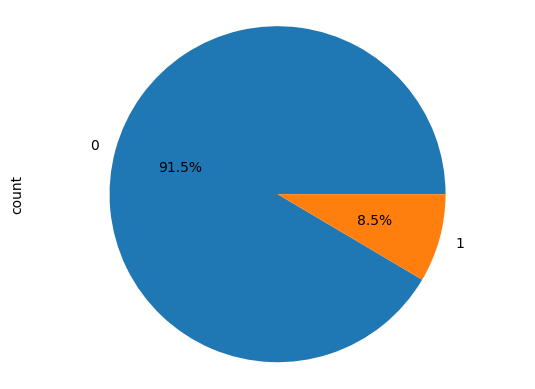

In [38]:
# pie chart for positve and negative diabetes cases

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
data['diabetes'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax)
ax.axis('equal')
plt.show()

In this [link](https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets), Google describes that this is only a moderate imbalance. It is stated that it is ok, if we just train with batches where the minority class is represented with a few values. Since we have an imbalance of c.a. 100 : 9, a batch size of 128 would result in 11 minority examples in average, which is acceptable.

# 4. Data Preprocessing

TODO: just drop smoking history, scale numeric values, encode non-numeric values



In [39]:
cleaned_data = pd.DataFrame()

## 4.1. Null Values
Let's drop the column "smoking_history":

In [40]:
# drop column "smoking history" from the dataset

data = data.drop('smoking_history', axis=1)

## 4.2. Encode Values

In [41]:
# encode the column gender with OneHotEncoding
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')

encoded_data = pd.DataFrame(encoder.fit_transform(data[["gender"]]).toarray(), columns=['isFemale', 'isMale'])

encoded_data


,isFemale,isMale
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
99995,1.0,0.0
99996,1.0,0.0
99997,0.0,1.0
99998,1.0,0.0


## 4.3. Scale Values

We can use the StandardScaler since we can assume that the numerical data follows a normal distribution.

In [42]:
# scale values with standard scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = pd.DataFrame(scaler.fit_transform(data[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]), columns=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'])

scaled_data

,age,bmi,HbA1c_level,blood_glucose_level
0,1.692704,-0.321056,1.001706,0.047704
1,0.538006,-0.000116,1.001706,-1.426210
2,-0.616691,-0.000116,0.161108,0.489878
3,-0.261399,-0.583232,-0.492690,0.416183
4,1.515058,-1.081970,-0.679490,0.416183
...,...,...,...,...
99995,1.692704,-0.000116,0.628107,-1.180558
99996,-1.771388,-1.499343,0.908306,-0.934905
99997,1.070944,0.076729,0.161108,0.416183
99998,-0.794336,1.220361,-1.426688,-0.934905


## 4.4. Conjoining the processed values

In [43]:
cleaned_data = pd.concat([scaled_data, encoded_data, data[['hypertension','heart_disease','diabetes']]], axis=1)
cleaned_data.head(10)

,age,bmi,HbA1c_level,blood_glucose_level,isFemale,isMale,hypertension,heart_disease,diabetes
0,1.692704,-0.321056,1.001706,0.047704,1.0,0.0,0,1,0
1,0.538006,-0.000116,1.001706,-1.426210,1.0,0.0,0,0,0
2,-0.616691,-0.000116,0.161108,0.489878,0.0,1.0,0,0,0
3,-0.261399,-0.583232,-0.492690,0.416183,1.0,0.0,0,0,0
4,1.515058,-1.081970,-0.679490,0.416183,0.0,1.0,1,1,0
5,-0.971982,-0.000116,1.001706,-1.303384,1.0,0.0,0,0,0
6,0.093892,-1.207032,0.908306,1.521618,1.0,0.0,0,0,1
7,1.648292,-0.521455,0.161108,-1.303384,1.0,0.0,0,0,0
8,0.005069,0.952158,-0.679490,0.170530,0.0,1.0,0,0,0
9,-0.439045,-0.000116,-0.492690,-0.934905,1.0,0.0,0,0,0


## 4.5. Splitting the Data

We need to make a train test val split. Lets do something like 7 : 1,5 : 1,5

In [44]:
# train/test split of data

from sklearn.model_selection import train_test_split

X = cleaned_data.drop('diabetes', axis=1)
y = cleaned_data['diabetes']

X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.3, random_state=random_state, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=random_state, stratify=y_test_val)

# 5. Classification with MLPClassifier

Now, let's get to the fun part: *Training a Neural Network*
What we will do is we will first find out the best parameters for the MLPClassifier. After that we will train a final model and analyze the train and validation loss curve. Let's start with finding out the best parameters for our MLPClassifier.

We will let AI generate some values for hyperparameters and limit CV to 4 because I don't have infinite computation power on my laptop...

In [45]:
# find out best hyperparameters for the mlp classifier using grid search and mlp classifier

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from time import time;

time_start = time()

mlp = MLPClassifier(random_state=random_state)

parameter_space = {
    'hidden_layer_sizes': [(20,20,), (30, 30,), (40,40,), (20,30,), (30,20,), (40,30,), (30,40,)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [128],
    'random_state': [random_state],
}

clf = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=4)
clf.fit(X_train, y_train)

time_end = time()

print('Best parameters found:\n', clf.best_params_)
print('Best score found:\n', clf.best_score_)
print('Time taken for grid search:', int(time_end - time_start) // 60 , 'minutes and ', int(time_end - time_start) % 60, 'seconds')

Best parameters found:
 {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (30, 40), 'learning_rate': 'constant', 'random_state': 5, 'solver': 'adam'}
Best score found:
 0.9713999999999999
Time taken for grid search: 8 minutes and  47 seconds


Well I didn't generate EVERYTHING, I also added other possiblities to "hidden_layer_sizes" (only for two hidden layers beacause AI and me think that 2 are enough...). If you paid attention, the batch_size is fixed to 128 because of the reason mentioned above (yk because of imbalanced labels).

An accuracy of 97% is very good. Now, we will train the model with the parameters returned but this time, we will use early_stopping = True so that some of the data is considered as validation data and trained accordingly.

We are doing this to be able to view the loss curve and the score curve of the validation data:

(Even though the assignment also requests the train accuracy curve and validation loss curve, the MLPClassifier does not store the necessary values for those two curves. Therefore, only the two aforementioned data is plotted...)

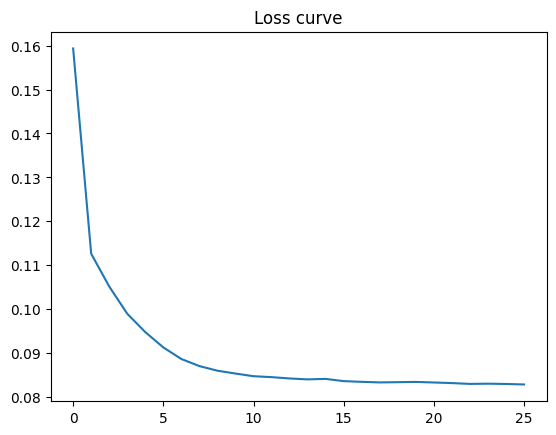

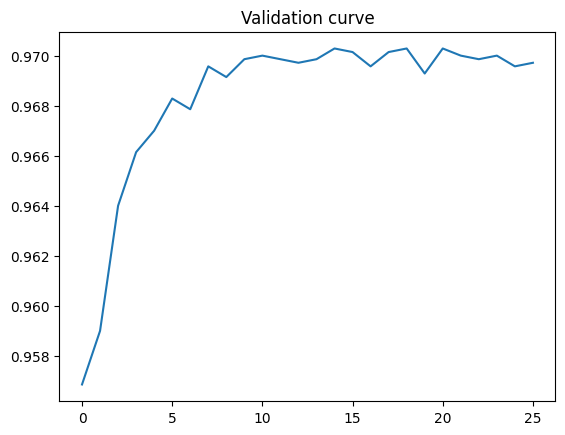

Training accuracy: 0.9711857142857143
Validation accuracy: 0.9697142857142858
Validation accuracy of X_val: 0.9726666666666667


In [46]:
# train the mlp classifier with the best hyperparameters also using early stopping

best_mlp_clf = MLPClassifier(hidden_layer_sizes=clf.best_params_['hidden_layer_sizes'],
                                activation=clf.best_params_['activation'],
                                solver=clf.best_params_['solver'],
                                alpha=clf.best_params_['alpha'],
                                learning_rate=clf.best_params_['learning_rate'],
                                batch_size=clf.best_params_['batch_size'],
                                random_state=random_state,
                                early_stopping=True,
                                validation_fraction=0.1)

best_mlp_clf.fit(X_train, y_train)

# plot the loss curve and the validation accuracy curve

plt.plot(best_mlp_clf.loss_curve_)
plt.title('Loss curve')
plt.show()

plt.plot(best_mlp_clf.validation_scores_)
plt.title('Validation curve')
plt.show()

print('Training accuracy:', best_mlp_clf.score(X_train, y_train))
print('Validation accuracy:', best_mlp_clf.validation_scores_[-1])
print('Validation accuracy of X_val:', best_mlp_clf.score(X_val, y_val))

WOW. These values look GREAT. Alright so as you can see in the above graph, the loss goes down with every epoch. But, looking at the validation accuracy graph, it tells us that this sometimes caused the val_accuracy go down, too. However, it also important to note that the value difference in those little bumps is VERY low. We are talking about a accuracy difference of 0.2% at max. You can also immediately notice that on epoch 1, the accuracy is still very high (at a whopping 95.8%). But let's analyze if its just the accuracy or other scores also are that satisfactory:

F1 score: 0.8096564531104921
Precision: 0.9920364050056882
Recall: 0.683921568627451
Confusion matrix:
 [[13718     7]
 [  403   872]]


<Axes: >

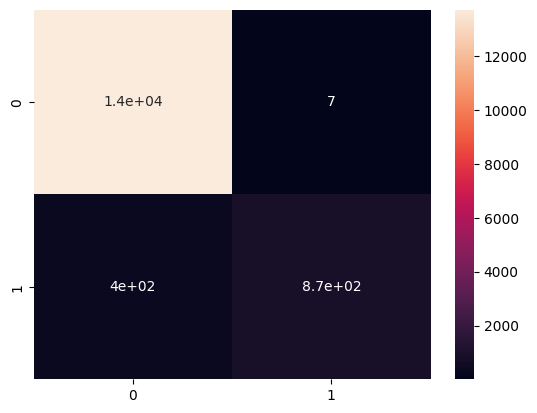

In [47]:
# find out other metrics of performance like f1 score, precision, recall, confusion matrix for the best_mlp_clf

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns

y_pred = best_mlp_clf.predict(X_val)

print('F1 score:', f1_score(y_val, y_pred))
print('Precision:', precision_score(y_val, y_pred))
print('Recall:', recall_score(y_val, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_val, y_pred))

# plot the confusion matrix

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True)

(Btw these scores are only for validation data only - the final evaluation of the model will be at the end of this work with the test_data)

So our model is pretty good actually with a high accuracy, precision, F1 score, etc.
But the main problem is on the mildly low recall (69%). This may be due to the imbalance we talked about previously. But still, we will decide the fate of our model at the very end of this work...

Before that, let's try to get a model as good as - or better than - the current one using Keras:

# 6. Classification with Keras

This time, we cannot use GridSearchCV, so we will try out the KerasTuner (which should ultimately do the same):

(PS: before being able to execute the code below (yes, the two imports...), I almost cried because of dependency issues but I figured out how to do it. Numpy has been upgraded (2.0.2) by uninstalling it and installing tensorflow (2.18.0) which installed numpy by itself resolving issues. For installing keras_tuner, I couldn't use the anaconda virtual environment because then it would be too simple, right? So I created a venv by myself, made sure it has notebook configurations and installed every. single. dependency. manually.)

![this is fine](./data/this_is_fine.png)

In [48]:
import tensorflow as tf
import keras_tuner as kt

For hyperparameter optimization we will use the hyperband method of keras tuner. Therefore, we will need to define a class first:

In [49]:
class ClfHyperModel(kt.HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.InputLayer(input_shape=(self.input_shape,)))
        for i in range(hp.Int('num_layers', 2, 3)):
            model.add(tf.keras.layers.Dense(units=hp.Int('units_' + str(i), 20, 40, 10),
                                            activation=hp.Choice('activation_' + str(i), ['relu', 'tanh'])))
        model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
        model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
        return model

We will try out the same things BUT with the difference that there may be 2-3 layers instad of just 2 in the preivous implementation. And we also added some values for the learning_rate.

If you look closely, we add one layer at the end containing only one node. This is because for binary classification, one node is enough since you can take the sigmoid activation, and et voila! We also use binary_crossentropy because cross entropy is used as the loss function for classificaton problems (and binary crossentropy for binary classification)

**IMPORTANT:** I have no idea why but when running the code below a second time, the time was only 0.3 seconds (!). I researched, googled, etc... but couldn't find out why, maybe because the keras_tuner caches results? Idk. So I will just note the time it took the first time right here: 5 min and 20 sec.

In [50]:
# run the hyperparameter search for the keras tuner with the ClfHyperModel and record the time spent

time_start = time()

hypermodel = ClfHyperModel(input_shape=X_train.shape[1])

hyperband_tuner = kt.Hyperband(
    hypermodel, objective="val_accuracy", seed=random_state,
    max_epochs=30, factor=3, hyperband_iterations=2)

hyperband_tuner.search(X_train, y_train, epochs=30,
                       validation_data=(X_val, y_val))

time_end = time()

print('Time taken for hyperparameter search:', int(time_end - time_start) // 60 , 'minutes and ', int(time_end - time_start) % 60, 'seconds')

# print best val accuracy and best hyperparameters

best_hps = hyperband_tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best val accuracy:', hyperband_tuner.oracle.get_best_trials(1)[0].score)
print('Best hyperparameters:', best_hps.values)


Reloading Tuner from .\untitled_project\tuner0.json


Time taken for hyperparameter search: 0 minutes and  0 seconds
Best val accuracy: 0.9739999771118164
Best hyperparameters: {'num_layers': 3, 'units_0': 40, 'activation_0': 'relu', 'units_1': 20, 'activation_1': 'relu', 'learning_rate': 0.01, 'units_2': 30, 'activation_2': 'relu', 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 1, 'tuner/trial_id': '0152'}


Ok, looking good as always. Let's visualize the accuracy and loss curves for both train and validation:

In [51]:
# plot the loss and accuracy curves for both train and validation by creating the best model manually

best_tf_model = tf.keras.Sequential()
best_tf_model.add(tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)))
for i in range(best_hps.get('num_layers')):
    best_tf_model.add(tf.keras.layers.Dense(units=best_hps.get('units_' + str(i)),
                                            activation=best_hps.get('activation_' + str(i))))

best_tf_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
best_tf_model.compile(optimizer=tf.keras.optimizers.Adam(best_hps.get('learning_rate')),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history = best_tf_model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30


c:\Users\yasin\Desktop\Dokumeeente\HTLdocs\JG5\DSAI\miniprojekt-1\.env\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9599 - loss: 0.1161 - val_accuracy: 0.9728 - val_loss: 0.0824
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9680 - loss: 0.0924 - val_accuracy: 0.9705 - val_loss: 0.0832
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9700 - loss: 0.0867 - val_accuracy: 0.9691 - val_loss: 0.0859
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9708 - loss: 0.0867 - val_accuracy: 0.9713 - val_loss: 0.0818
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9692 - loss: 0.0885 - val_accuracy: 0.9732 - val_loss: 0.0791
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9713 - loss: 0.0837 - val_accuracy: 0.9644 - val_loss: 0.0937
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9689 - loss: 0.0879 - val_accuracy: 0.9731 - val_loss: 0.0799
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9696 - loss: 0.0881 - val_accurac

The first thing you notice is that the time for hyperparameter optimization for sklearn.MLPClassifier takes double the time compared to tf.Keras (even though keras had more parameters) but training the model with the parameters takes much longer with keras than mlpClassifier. Alright, now it's time to look at our curves:

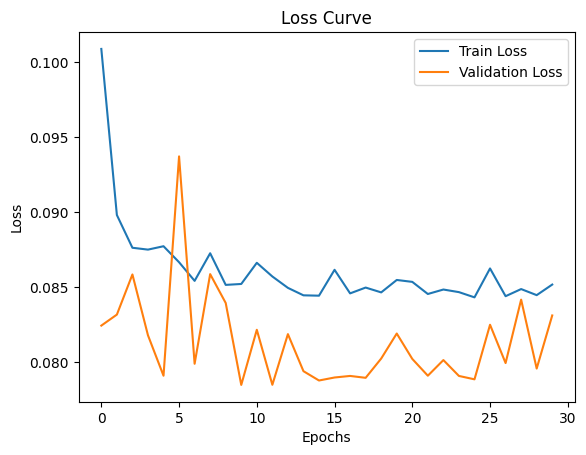

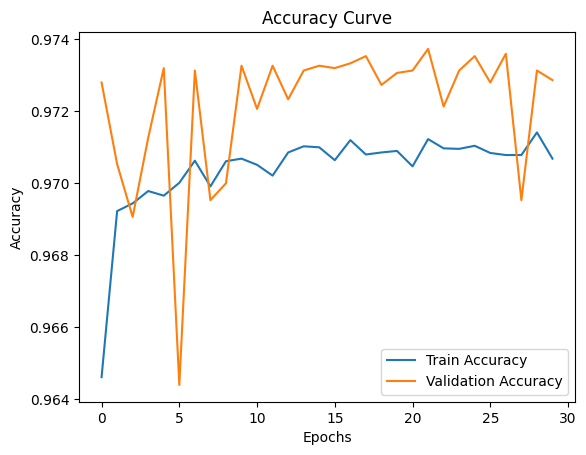

In [52]:
# Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.legend(loc="upper right")  # Correct usage of legend location
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.legend(loc="lower right")  # Correct usage of legend location
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In first glance, you can see that the train loss curve looks pretty same as the MLPClassfier's loss curve. The validation accuracy also shows some similarities. Now, it's time for the final evaluation...

# 7. Evaluation

Now it's time to test our models. We should store y_pred of our test data for both models.

In [53]:
# use X_test to save y_predictions the best_tf_model and best_mlp_clf

y_pred_tf = best_tf_model.predict(X_test)
y_pred_tf = (y_pred_tf > 0.5).astype(int)

y_pred_mlp = best_mlp_clf.predict(X_test)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step


Let's store the performance values for our models and display them as bar graphs accordingly:

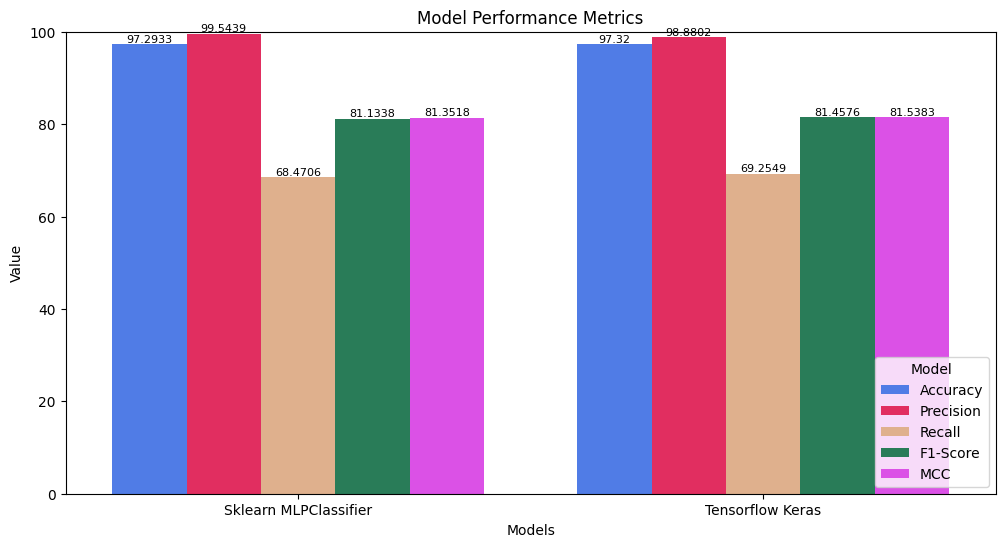

In [54]:
# store the scores Accuracy, Precisioin, Recall, F1 score, MCC for both the models
#    and display them in a bar chart, one group for MLPClassifier and one group for the Keras model

colors = ["#3772FF", "#FF1053", "#edae7f", "#1b8a5a", "#F038FF"]
cat_palette = sns.color_palette(colors)

score_data = {
    'Model': ['Sklearn MLPClassifier', 'Tensorflow Keras'],
    'Accuracy': [accuracy_score(y_test, y_pred_mlp) * 100, accuracy_score(y_test, y_pred_tf) * 100],
    'Precision': [precision_score(y_test, y_pred_mlp) * 100, precision_score(y_test, y_pred_tf) * 100],
    'Recall': [recall_score(y_test, y_pred_mlp) * 100, recall_score(y_test, y_pred_tf) * 100],
    'F1-Score': [f1_score(y_test, y_pred_mlp) * 100, f1_score(y_test, y_pred_tf) * 100],
    'MCC': [matthews_corrcoef(y_test, y_pred_mlp) * 100, matthews_corrcoef(y_test, y_pred_tf) * 100]
}

score_table = pd.DataFrame(score_data)

score_table_melted = score_table.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
bp = sns.barplot(x='Model', y='Value', hue='Metric', data=score_table_melted, palette=cat_palette) 

for i in bp.containers:
    bp.bar_label(i, fontsize=8)

plt.title('Model Performance Metrics')
plt.xlabel('Models')
plt.ylabel('Value')
plt.ylim(0, 100)
plt.legend(title='Model', loc='lower right')
plt.show()


If you can remember the values from last year, you should see that there are some improvements. For reference, here is the same graph from last year:

![values from last year](./data/graphs.png)



In this analysis, we observed that the MLP and Keras models perform almost identically, making a direct comparison between the two somewhat redundant. However, the overall performance of this year's neural network models is notably different and improved compared to last year's models.

This year, the models achieved higher accuracy and significantly better precision. This indicates that the models are less prone to labeling instances as positive incorrectly, in contrast to last year when they tended to overpredict positives. As a result, this year's models have successfully addressed the issue of data imbalance, leading to better F1 and MCC scores, which measure the overall performance and reliability of the models.

Despite these improvements, one critical limitation remains: the recall is relatively low. A low recall means that a significant portion of diabetic cases may go undetected. While the higher precision reduces false positives, the trade-off is the risk of leaving some individuals undiagnosed, which could result in severe health consequences. Therefore, while the current models demonstrate significant progress, they must be refined further to increase recall, ensuring that they are practical and safe for real-world application in medical diagnostics.

# 8. Conclusion
This project evaluates two machine learning models, MLPClassifier (Scikit-learn) and a custom Keras model, for diabetes classification. Both models demonstrate high performance, achieving similar metrics with accuracy exceeding 97% and improvements in precision and F1 scores compared to last year's models. This reflects success in mitigating the effects of data imbalance.

However, a key limitation is the low recall (~68%-69%), indicating that many diabetic cases remain undetected. This is a critical concern, as undiagnosed diabetes can lead to severe health issues. While the models exhibit high precision, they prioritize avoiding false positives, which risks leaving true cases undiagnosed.

To improve real-world applicability, future efforts should focus on increasing recall without compromising overall performance. This may involve addressing class imbalance further, exploring alternative architectures, or using ensemble techniques to balance precision and recall effectively.